# **Basic Settings**

In [1]:
import os

def find_file(base_path, filename):
    for root, dirs, files in os.walk(base_path):
        if filename in files:
            return root
    return None

BASE_PATH = find_file("./", "train.csv")

print("Using path:", BASE_PATH)
os.chdir(BASE_PATH)

Using path: ./


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error

from xgboost import XGBRegressor

In [3]:
import os
print(os.listdir())

['260402_ML.ipynb', 'cols.txt', 'sample_submission.csv', 'submission.csv', 'test.csv', 'train.csv', '_260402_ML.ipynb', '_sample_submission.csv', '_test.csv', '_train.csv']


# **1. Data Analysis and Basic Preprocessing for float**
## **(1) How to handle float values** : *rider_rating Column*

i. Data Load **(! Fill in Blank (########) !)**

In [4]:
import pandas as pd

df = pd.read_csv("test.csv")

# Select rider_rating column
rating = df["rider_rating"]      # Replace the ###### part

# Verification
rating.head()

0    4.5
1    4.3
2    4.9
3    4.3
4    4.7
Name: rider_rating, dtype: float64

ii. Missing value Verification

In [5]:
# Numb. of missing value
num_missing = rating.isna().sum()

# Ratio regarding to the numb. of total data
missing_ratio = rating.isna().mean()

print(f"Missing count: {num_missing}")
print(f"Missing ratio: {missing_ratio:.4f}")

Missing count: 109
Missing ratio: 0.0439


iii. Column Analysis

In [6]:
print(rating.describe())

count    2375.000000
mean        4.638316
std         0.325841
min         1.000000
25%         4.500000
50%         4.700000
75%         4.900000
max         6.000000
Name: rider_rating, dtype: float64


## **(2) Distribution Analysis** : *rider_rating Column*

i. Histogram Plot **(! Fill in Blank (########) !)**

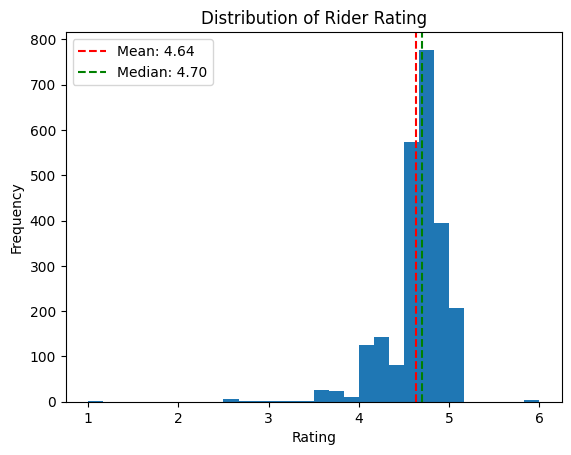

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Data Load
df = pd.read_csv("test.csv")
rating = df["rider_rating"].dropna()

# mean, median calculation
mean_val = rating.mean()          # Replace the ###### part
median_val = rating.median()      # Replace the ###### part

# Histogram
plt.figure()
plt.hist(rating, bins=30)       # Replace the ###### part

# Add mean, median line
plt.axvline(mean_val,color='r', linestyle='--', label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val,color='g', linestyle='--', label=f"Median: {median_val:.2f}")

# Title & Lables
plt.title("Distribution of Rider Rating")
plt.xlabel("Rating")
plt.ylabel("Frequency")

# Legend plot
plt.legend()

plt.show()

ii. Box Plot **(! Fill in Blank (########) !)**

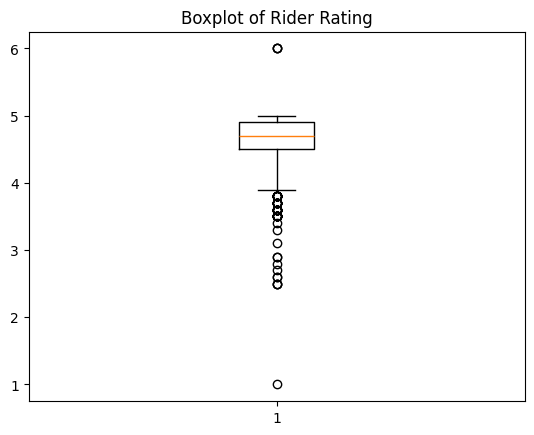

In [8]:
plt.figure()
plt.boxplot(rating.dropna(), vert=True)    # Replace the ###### part

plt.title("Boxplot of Rider Rating")

plt.show()

## **(3) Median Imputation + Missing Indicator** : *rider_rating Column*

i. Implementation **(! Fill in Blank (########) !)**

In [9]:
import pandas as pd

# Data Load
df = pd.read_csv("test.csv")

# Copy rider_rating Column
df_model = df[["rider_rating"]].copy()

# 1) Generate missing indicator
df_model["rider_rating_missing"] = df_model["rider_rating"].fillna(0).astype(int)      # Replace the ###### part

# 2) median calculation
median_rating = df_model["rider_rating"].median()

# 3) median imputation
df_model["rider_rating_imputed"] = df_model["rider_rating"].fillna(median_rating)

print(df_model.head(20))
print(f"Median used for imputation: {median_rating:.2f}")

    rider_rating  rider_rating_missing  rider_rating_imputed
0            4.5                     4                   4.5
1            4.3                     4                   4.3
2            4.9                     4                   4.9
3            4.3                     4                   4.3
4            4.7                     4                   4.7
5            NaN                     0                   4.7
6            4.6                     4                   4.6
7            4.6                     4                   4.6
8            4.6                     4                   4.6
9            4.7                     4                   4.7
10           4.7                     4                   4.7
11           4.4                     4                   4.4
12           4.7                     4                   4.7
13           4.8                     4                   4.8
14           4.9                     4                   4.9
15           4.9        

# **2. Data Analysis and Basic Preprocessing for string**

## **(1) Find Unique Categories** : *weather Column*

i. Data Load and Check the Missing Values **(! Fill in Blank (########) !)**

In [10]:
import pandas as pd

# Data Load
df = pd.read_csv("test.csv")

# Get weather Column
weather = df["weather"]            # Replace the ###### part

# 1. Find Unique Categories in weather Column (including NaN)
print("Unique categories (including NaN):")
print(weather.unique())

# 2. Find the numb. of data in each Category (including NaN)
print("\nValue counts (including NaN):")
print(weather.value_counts(dropna=False))

# 3. Number of missing values
num_missing = weather.isna().sum()
print(f"\nMissing count: {num_missing}")

Unique categories (including NaN):
['clear_sky' 'high_wind' 'foggy' 'sandstorm' nan 'overcast' 'storm']

Value counts (including NaN):
weather
sandstorm    431
foggy        424
high_wind    410
overcast     399
storm        397
clear_sky    387
NaN           36
Name: count, dtype: int64

Missing count: 36


## **(2) Mode Imputation + One Hot Encoding (OHE)** : *weather Column*

i. OHE Implementation **(! Fill in Blank (########) !)**

In [11]:
import pandas as pd

# Data Load
df = pd.read_csv("test.csv")

# Copy weather Column
weather_df = df[["weather"]].copy()

# 1. Find Mode
mode_weather = weather_df["weather"].mode()[0]
print(f"Mode used for imputation: {mode_weather}")

# 2. Replace the missing values as mode
weather_df["weather"] = weather_df["weather"].fillna(mode_weather)

# 3. One-Hot Encoding
weather_ohe = pd.get_dummies(weather_df["weather"], prefix="weather")       # Replace the ###### part

# 4. Check the Result
print("\nEncoded features:")
print(weather_ohe.head())

print("\nShape:", weather_ohe.shape)

Mode used for imputation: sandstorm

Encoded features:
   weather_clear_sky  weather_foggy  weather_high_wind  weather_overcast  \
0               True          False              False             False   
1              False          False               True             False   
2              False           True              False             False   
3              False          False              False             False   
4              False          False              False             False   

   weather_sandstorm  weather_storm  
0              False          False  
1              False          False  
2              False          False  
3               True          False  
4               True          False  

Shape: (2484, 6)


# **3. Model Overview : XGBoost**

## **(0) Preparing Data** : *N/A Filling, Format Encoding, One Hot Encoding*

In [75]:
import math

import pandas as pd
import numpy as np
from itertools import product, combinations

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from xgboost import XGBRegressor, XGBRFRegressor

# Define all neccessary variables including the ones are used below.  
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"
SAMPLE_SUB_PATH = "sample_submission.csv"
OUTPUT_SUB_PATH = "submission.csv"
DEVICE = "cpu"

Regressor = XGBRegressor

ALL_COLS = [
    ("rider_age", "num"),
    ("rider_rating", "num"),
    ("restaurant_latitude", "num"),
    ("restaurant_longitude", "num"),
    ("delivery_latitude", "num"),
    ("delivery_longitude", "num"),
    ("vehicle_condition", "num"),
    ("num_orders", "num"),

    ("weather", "cat"),
    ("traffic_density", "cat"),
    ("order_type", "cat"),
    ("vehicle_type", "cat"),
    ("is_festival", "cat"),
    ("city", "cat"),

    ("order_date", "date"),
    ("order_time", "time"),
    ("pickup_time", "time"),

    ("delivery_time", "num"),
]
TARGET_COL = ALL_COLS[-1]

def fill_na_with_median(df, col):
    med = df[col].median()
    df[f"{col}_missing"] = df[col].isna().astype(int)
    df[f"{col}_imputed"] = df[col].fillna(med)
    
    return df

def fill_na_with_mode(df, col):
    mode = df[col].mode()[0]
    df[f"{col}_missing"] = df[col].isna().astype(int)
    df[f"{col}_imputed"] = df[col].fillna(mode)
    df[col] = df[col].fillna(mode)

    return df

def get_one_hot(df, col):
    return pd.get_dummies(df[col], prefix=col, dtype=int)

def parse_date(s):
    raise NotImplementedError("parse_data not implemented")

def encode_date(df, col):
    df[col] = df[col].map(parse_date)

    return df

def parse_time(t):
    if isinstance(t, float):
        return int(t * 24 * 60) if not math.isnan(t) else float('nan')

    t = t.lower().strip()
    if any(s in t for s in ['am', 'pm']):
        offset = 0 if 'am' in t else 12 * 60
        t = t.replace('am', '')
        t = t.replace('pm', '')

        hh, mm, *_ = t.split(':')
        hh = int(hh.strip())
        mm = int(mm.strip())
        return hh * 60 + mm + offset
    elif ':' in t:
        hh, mm, *ss = t.split(':')
        hh = int(hh.strip())
        mm = int(mm.strip())
        return hh * 60 + mm
    else:
        try:
            return int(float(t) * 24 * 60) if not math.isnan(float(t)) else float('nan')
        except:
            raise NotImplementedError(f'unkndown format: {t}')
    
def encode_time(df, col):
    df[col] = df[col].map(parse_time)

    return df

def parse_traffic(s):
    if s == "low":
        return 0
    elif s == "medium":
        return 1
    elif s == "high":
        return 2
    elif s == "jam":
        return 3
    
    raise Exception(f"unknown value for traffic {s}")

def encode_traffic(df, col):
    df[col] = df[col].map(parse_traffic)

    return df

def get_raw_df(path, cols=ALL_COLS):
    csv_cols = pd.read_csv(path, nrows=0).columns
    valid_cols = [c for c, _ in cols if c in csv_cols]

    return pd.read_csv(path)[[*valid_cols]]

def get_df(path, cols=ALL_COLS, is_test=False):
    ret = get_raw_df(path, cols)
    
    for col, kind in cols:
        if col == TARGET_COL[0] and is_test:
            continue

        if col == "traffic_density":
            ret = fill_na_with_mode(ret, col)
            ret == encode_traffic(ret, f"{col}_imputed")
        elif kind == "num":
            ret = fill_na_with_median(ret, col)
        elif kind == "cat":
            ret = fill_na_with_mode(ret, col)
        elif kind == "date":
            continue
            ret = fill_na_with_mode(ret, col)
            ret = encode_date(ret, f"{col}_imputed")
        elif kind == "time":
            ret = fill_na_with_mode(ret, col)
            ret = encode_time(ret, f"{col}_imputed")
        else:
            raise Exception("unreachable")
        
    return ret

def get_data(path, is_test=False):
    ret = pd.DataFrame()
    df = get_df(path, is_test=is_test)
    if not is_test:
        ret[TARGET_COL[0]] = df[TARGET_COL[0]]
    
    # Numerical Columns (imputed, missing)
    ret["rider_age_imputed"] = df["rider_age_imputed"]
    ret["rider_rating_imputed"] = df["rider_rating_imputed"]
    ret["traffic_density_imputed"] = df["traffic_density_imputed"]
    ret["vehicle_condition_imputed"] = df["vehicle_condition_imputed"]
    ret["num_orders_imputed"] = df["num_orders_imputed"]

    # Distance between Restaurant and Delivery site
    d_lat = df["restaurant_latitude_imputed"] - df["delivery_latitude_imputed"]
    d_long = df["restaurant_longitude_imputed"] - df["delivery_longitude_imputed"]
    ret["restaurant_dist"] = np.sqrt(d_lat.pow(2) + d_long.pow(2))

    # Time diff from Order to Pick of the delivery
    d_time = df["pickup_time_imputed"] - df["order_time_imputed"]
    ret["order_to_pick"] = d_time

    # Imputed Indicators
    ret["rider_age_missing"] = df["rider_age_missing"]
    ret["rider_rating_missing"] = df["rider_rating_missing"]
    ret["traffic_density_missing"] = df["traffic_density_missing"]
    ret["vehicle_condition_missing"] = df["vehicle_condition_missing"]
    ret["num_orders_missing"] = df["num_orders_missing"]
    
    dist_conf = 100 * (4 - (df["restaurant_latitude_missing"] + df["delivery_latitude_missing"] + df["restaurant_longitude_missing"] - df["delivery_longitude_missing"])) / 4
    ret["restaurant_dist_conf"] = dist_conf

    op_conf = 100 * (2 - (df["pickup_time_missing"] + df["order_time_missing"])) / 2
    ret["order_to_pick_conf"] = op_conf

    # One Hot Missing
    ret["weather_missing"] = df["weather_missing"]
    ret["order_type_missing"] = df["order_type_missing"]
    ret["vehicle_type_missing"] = df["vehicle_type_missing"]
    ret["is_festival_missing"] = df["is_festival_missing"]
    ret["city_missing"] = df["city_missing"]
    
    # Interactions
    # inter_tup = [
    #     ["rider_rating_imputed", "num_orders_imputed"],
    #     ["restaurant_dist", "traffic_density_imputed"],
    #     ["order_to_pick", "restaurant_dist"],
    # ]
    # for tup in inter_tup:
    #     for count in range(2, len(tup)):
    #         for t in combinations(tup, count):
    #             temp = ret[tup[0]]
    #             for i in range(1, count + 1):
    #                 temp *= ret[tup[i]]
    #                 
    #             name = "_".join(tup)
    #             ret[name] = temp

    # One Hot
    one_hots = []
    one_hots.append(get_one_hot(df, "weather_imputed"))
    one_hots.append(get_one_hot(df, "order_type_imputed"))
    one_hots.append(get_one_hot(df, "vehicle_type_imputed"))
    one_hots.append(get_one_hot(df, "is_festival_imputed"))
    one_hots.append(get_one_hot(df, "city_imputed"))

    return (ret, one_hots)

## **(1) Grid Search in XGBoost** : *rider_rating & weather Column*

In [80]:
# ==============================
# Get Train Data
# ==============================
train_data = get_data(TRAIN_PATH)

X = pd.concat([
        train_data[0].drop(TARGET_COL[0], axis=1),
        *train_data[1],
    ], axis=1)
y = train_data[0][TARGET_COL[0]]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ==============================
# Prepare Param Grid
# ==============================

param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.08, 0.1, 0.12],
    "max_depth": [7, 8, 9],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [11, 13, 15, 17],
}

param_names = list(param_grid.keys())
param_combinations = list(product(*param_grid.values()))

print(f"\nTotal combinations: {len(param_combinations)}")

# =========================
# Implement Grid Search
# =========================
results = []

for idx, values in enumerate(param_combinations, start=1):
    params = dict(zip(param_names, values))

    model = Regressor(
        device=DEVICE,
        booster="gbtree",
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        min_child_weight=params["min_child_weight"],
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)

    pred_valid = model.predict(X_valid)
    mape = mean_absolute_percentage_error(y_valid, pred_valid)

    result_row = params.copy()
    result_row["valid_mape"] = mape
    results.append(result_row)

    print(f"[{idx:03d}/{len(param_combinations)}] "
          f"MAPE={mape:.6f} | {params}")

# DataFrame Result
results_df = pd.DataFrame(results).sort_values("valid_mape").reset_index(drop=True)

# =========================
# Print the Result
# =========================
print("\n" + "="*60)
print("Best parameter combination")
print("="*60)
print(results_df.iloc[0])

print("\n" + "="*60)
print("Top 3 parameter combinations")
print("="*60)
print(results_df.head(3))


Total combinations: 648
[001/648] MAPE=0.143426 | {'n_estimators': 50, 'learning_rate': 0.08, 'max_depth': 7, 'subsample': 0.8, 'colsample_bytree': 0.7, 'min_child_weight': 11}
[002/648] MAPE=0.143809 | {'n_estimators': 50, 'learning_rate': 0.08, 'max_depth': 7, 'subsample': 0.8, 'colsample_bytree': 0.7, 'min_child_weight': 13}
[003/648] MAPE=0.143972 | {'n_estimators': 50, 'learning_rate': 0.08, 'max_depth': 7, 'subsample': 0.8, 'colsample_bytree': 0.7, 'min_child_weight': 15}
[004/648] MAPE=0.144754 | {'n_estimators': 50, 'learning_rate': 0.08, 'max_depth': 7, 'subsample': 0.8, 'colsample_bytree': 0.7, 'min_child_weight': 17}
[005/648] MAPE=0.144759 | {'n_estimators': 50, 'learning_rate': 0.08, 'max_depth': 7, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 11}
[006/648] MAPE=0.143852 | {'n_estimators': 50, 'learning_rate': 0.08, 'max_depth': 7, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 13}
[007/648] MAPE=0.145440 | {'n_estimators': 50, 'learning_

## **(2) Submission with XGBoost** : *rider_rating & weather Column*

In [81]:
params = {
    "n_estimators": 200,
    "learning_rate": 0.1,
    "max_depth": 8,
    "subsample": 1,
    "colsample_bytree": 1,
    "min_child_weight": 13,
}

train_data = get_data(TRAIN_PATH)

# final X, y
X = pd.concat([
        train_data[0].drop(TARGET_COL[0], axis=1),
        *train_data[1],
    ], axis=1)
y = train_data[0][TARGET_COL[0]]

print("\nTrain feature columns:")
print(X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================
# Train / Vaild
# =========================
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = Regressor(
    device=DEVICE,
    booster="gbtree",
    n_estimators=params["n_estimators"],
    learning_rate=params["learning_rate"],
    max_depth=params["max_depth"],
    subsample=params["subsample"],
    colsample_bytree=params["colsample_bytree"],
    min_child_weight=params["min_child_weight"],
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X_train, y_train)

# MAPE of validation set
valid_pred = model.predict(X_valid)
valid_mape = mean_absolute_percentage_error(y_valid, valid_pred)
print(f"\nValidation MAPE: {valid_mape:.6f}")

final_model = Regressor(
    device=DEVICE,
    booster="gbtree",
    n_estimators=params["n_estimators"],
    learning_rate=params["learning_rate"],
    max_depth=params["max_depth"],
    subsample=params["subsample"],
    colsample_bytree=params["colsample_bytree"],
    min_child_weight=params["min_child_weight"],
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42
)

final_model.fit(X, y)

# =========================
# Test
# =========================
test_data = get_data(TEST_PATH, is_test=True)

X_test = pd.concat([
        test_data[0],
        *test_data[1],
    ], axis=1)

X_test = X_test.reindex(columns=X.columns, fill_value=0)

print("\nX_test shape:", X_test.shape)
print("X_test columns match train:", list(X_test.columns) == list(X.columns))

test_pred = final_model.predict(X_test)

print("\nFirst 5 predictions:")
print(test_pred[:5])

try:
    sample_sub = pd.read_csv(SAMPLE_SUB_PATH)
    print("\nLoaded sample_submission.csv")
    print("sample submission columns:", sample_sub.columns.tolist())


    pred_col_candidates = [col for col in sample_sub.columns if col.lower() != "id"]

    if len(pred_col_candidates) == 1:
        pred_col = pred_col_candidates[0]
    else:
        pred_col = TARGET_COL if TARGET_COL in sample_sub.columns else sample_sub.columns[-1]

    sample_sub[pred_col] = test_pred
    submission = sample_sub.copy()

except FileNotFoundError:
    print("\nsample_submission.csv not found -> creating submission manually")

    # id Column
    id_col = 'id'

    if id_col is not None:
        submission = pd.DataFrame({
            id_col: test_data[id_col],
            TARGET_COL: test_pred
        })
    else:
        submission = pd.DataFrame({
            TARGET_COL: test_pred
        })

# Save
submission.to_csv(OUTPUT_SUB_PATH, index=False)
print(f"\nSaved submission file: {OUTPUT_SUB_PATH}")
print(submission.head())


Train feature columns:
['rider_age_imputed', 'rider_rating_imputed', 'traffic_density_imputed', 'vehicle_condition_imputed', 'num_orders_imputed', 'restaurant_dist', 'order_to_pick', 'rider_age_missing', 'rider_rating_missing', 'traffic_density_missing', 'vehicle_condition_missing', 'num_orders_missing', 'restaurant_dist_conf', 'order_to_pick_conf', 'weather_missing', 'order_type_missing', 'vehicle_type_missing', 'is_festival_missing', 'city_missing', 'weather_imputed_clear_sky', 'weather_imputed_foggy', 'weather_imputed_high_wind', 'weather_imputed_overcast', 'weather_imputed_sandstorm', 'weather_imputed_storm', 'order_type_imputed_Buffet', 'order_type_imputed_Drinks', 'order_type_imputed_Meal', 'order_type_imputed_Snack', 'vehicle_type_imputed_bicycle', 'vehicle_type_imputed_e_scooter', 'vehicle_type_imputed_motorcycle', 'vehicle_type_imputed_scooter', 'is_festival_imputed_No', 'is_festival_imputed_X', 'is_festival_imputed_Yes', 'is_festival_imputed_y', 'city_imputed_Metropolitian',